### Fxn que genera clusters
#### Recibe:
- Df simétrico con las correlaciones
- Número de clusters esperados
#### Regresa
- Clusters con sus integrantes


Para hierarchy.linkage usar method='ward'

In [1]:
from scipy.cluster.hierarchy import linkage, fcluster
import pandas as pd
import numpy as np
from scipy.spatial.distance import squareform


from math import log
import networkx as nx
from freyrelab.nets import models
from freyrelab.regnets import regnet
from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet

from netective.structure.structure import pairwise_pearson_correlation, compare_networks, create_symmetric_heatmap

In [58]:
def get_clusters(corr_df, clust_num, ch_method: str = 'ward', ch_metric: str = 'euclidean'):
    dist_mtrx = round(1 - np.abs(corr_df.astype('float')), 4)
    linkage_mtrx = linkage(squareform(dist_mtrx), method=ch_method, metric=ch_metric) #TODO: validate , checks=False
    index = list(corr_df.index)
    cluster_vector = fcluster(linkage_mtrx, t = clust_num, criterion = 'maxclust')
    clusters = {i : [] for i in cluster_vector}
    {clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))}

    return clusters


In [4]:
# start instance of Abasy
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True) # select all regnets withour redundancy, keep the strong one if available
# regnet_ids = abasy.select_regnets('511145', strong=True) # select all regnets withour redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids) # get the regnets {regnet_id: regnet}


seed = 42
random_graph = {}

i = 0
hm_seed_size = 3
for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.scale_free_graph(n, seed=seed)
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)
    # hm_seed_size, iterations = find_closest_approximation(n)
    # random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(n=iterations, m=hm_seed_size)
    i += 1
    print(i/len(regnets), net_id, flush=True)

networks = {**regnets, **random_graph}


0.023809523809523808 100226_v2019_sA22-DBSCR15_eStrong
0.047619047619047616 158878_v2015_sRTB13
0.07142857142857142 158879_v2015_sRTB13
0.09523809523809523 160491_v2015_sRTB13
0.11904761904761904 186103_v2015_sRTB13
0.14285714285714285 196620_v2015_sRTB13
0.16666666666666666 196627_v2020_s21_eStrong
0.19047619047619047 198466_v2015_sRTB13
0.21428571428571427 199310_v2015_sRTB13
0.23809523809523808 208964_v2020_sRPA20_eStrong
0.2619047619047619 224308_v2008_sDBTBS08_eStrong
0.2857142857142857 273036_v2015_sRTB13
0.30952380952380953 282458_v2015_sRTB13
0.3333333333333333 282459_v2015_sRTB13
0.35714285714285715 301447_v2015_sRTB13
0.38095238095238093 316385_v2015_sRTB13
0.40476190476190477 319701_v2015_sRTB13
0.42857142857142855 331111_v2015_sRTB13
0.4523809523809524 331112_v2015_sRTB13
0.47619047619047616 340184_v2015_sRTB13
0.5 344601_v2015_sRTB13
0.5238095238095238 359786_v2015_sRTB13
0.5476190476190477 359787_v2015_sRTB13
0.5714285714285714 362663_v2015_sRTB13
0.5952380952380952 36410

In [5]:
networks = {name: RegNet(G) if not isinstance(G, (nx.DiGraph,RegNet)) else G for name, G in networks.items()}

networks = {i:nx.erdos_renyi_graph(100, 0.1, directed=True) for i in range(3)}

In [6]:
scalar, dists = compare_networks(networks=networks, norm='network', return_prop_dicts=True, workers=6)

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running 100226_v2019_sA22-DBSCR15_eStrong
Running 158878_v2015_sRTB13
Running 158879_v2015_sRTB13
Running 160491_v2015_sRTB13
Running 186103_v2015_sRTB13
Running 196620_v2015_sRTB13
Running 196627_v2020_s21_eStrong
Running 198466_v2015_sRTB13
Running 199310_v2015_sRTB13
Running 208964_v2020_sRPA20_eStrong
Running 224308_v2008_sDBTBS08_eStrong
Running 273036_v2015_sRTB13
Running 282458_v2015_sRTB13
Running 282459_v2015_sRTB13
Running 301447_v2015_sRTB13
Running 316385_v2015_sRTB13
Running 319701_v2015_sRTB13
Running 331111_v2015_sRTB13
Running 331112_v2015_sRTB13
Running 340184_v2015_sRTB13
Running 344601_v2015_sRTB13
Running 359786_v2015_sRTB13
Running 359787_v2015_sRTB13
Running 362663_v2015_sRTB13
Running 364106_v2015_sRTB13
Running 367830_v2015_sRTB13
Running 370551_v2015_sRTB13
Running 370552_v2015_sRTB13
Running 370554_v2015_sRTB13
Running 381754_v2015_sRTB13
Running 405955_v2015_sRTB13
Running 406558_v2015_sRTB13
Running 418127_v2015_sRTB13
Running 426430_v2015_sRTB13
Running 439

32it [00:10,  2.85it/s]                      

Error: cannot pickle 'dict_keys' object


208it [06:32,  1.89s/it]


c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


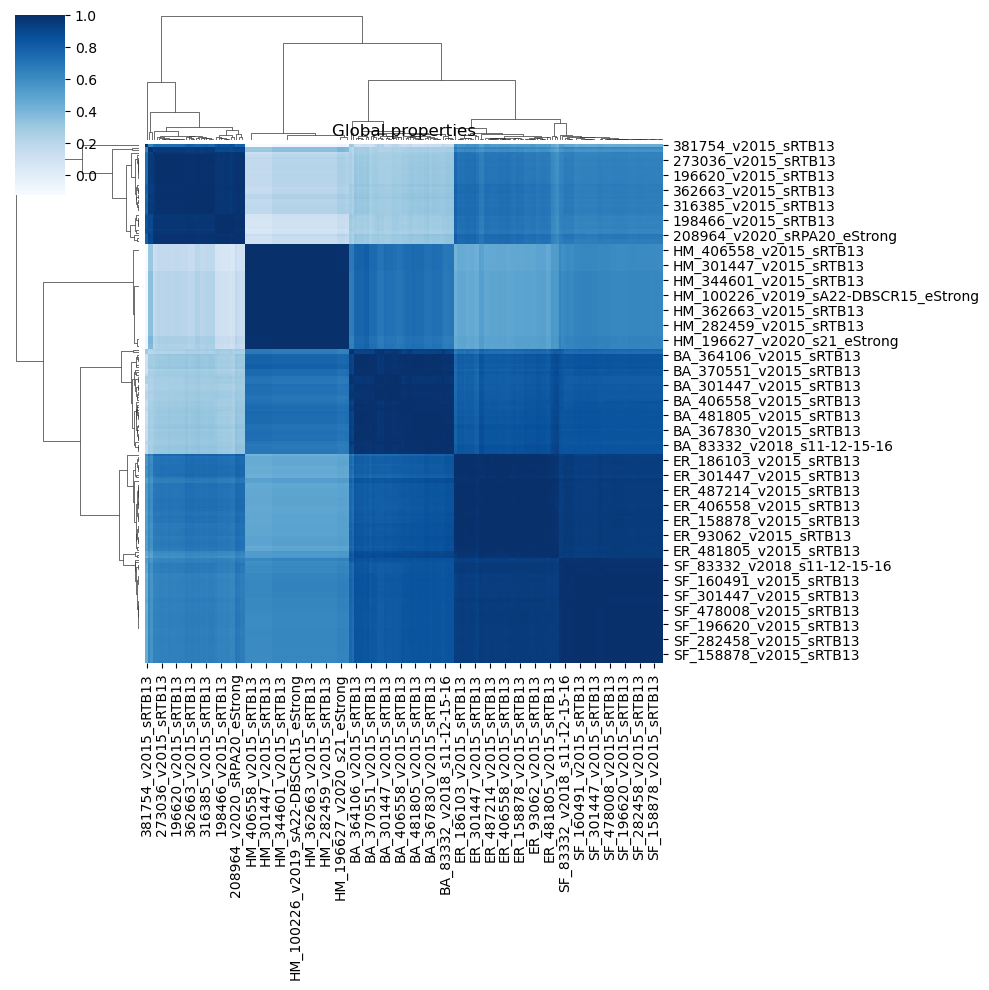

In [64]:
df = pairwise_pearson_correlation(scalar)
fig_scalar, _ = create_symmetric_heatmap(df, title=f"Global properties")

c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


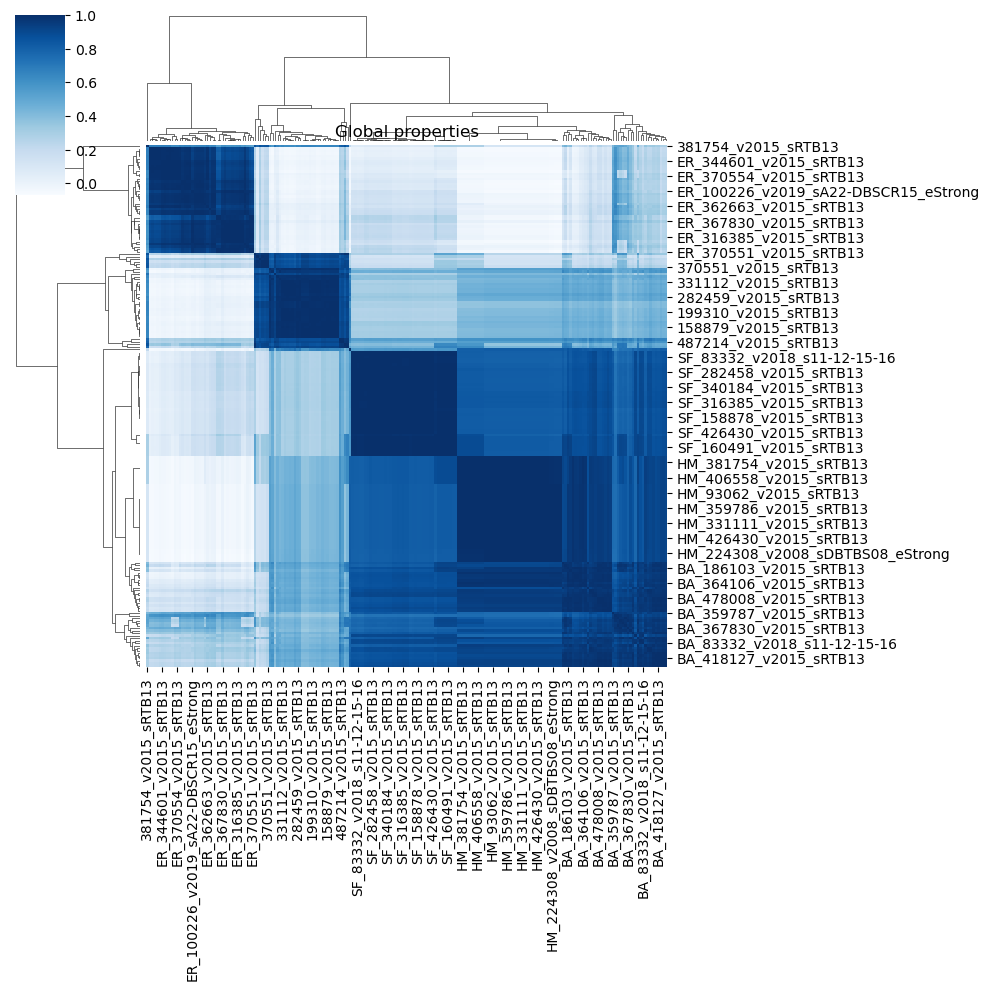

In [61]:
df_dists = pairwise_pearson_correlation(dists)
fig_scalar, _ = create_symmetric_heatmap(df_dists, title=f"Global properties")

In [29]:
result = get_clusters(df, 5)
result, df.index

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 2, 4, 1, 5, 2, 3,
        5, 4, 2, 3, 5, 4, 2, 3, 4, 5, 3, 5, 4, 2, 2, 5, 3, 4, 1, 3, 4, 5,
        2, 3, 4, 5, 2, 3, 4, 5, 2, 2, 3, 4, 5, 3, 3, 4, 5, 2, 4, 2, 2, 5,
        4, 3, 3, 5, 2, 3, 5, 2, 4, 5, 5, 2, 4, 4, 3, 5, 2, 4, 3, 2, 3, 4,
        3, 5, 5, 4, 2, 3, 4, 5, 2, 3, 4, 5, 2, 2, 3, 5, 4, 3, 3, 2, 4, 5,
        5, 4, 2, 3, 4, 5, 2, 3, 2, 5, 3, 4, 2, 4, 5, 2, 3, 5, 4, 3, 2, 4,
        5, 3, 4, 2, 5, 3, 5, 4, 3, 2, 2, 4, 5, 2, 3, 4, 3, 5, 4, 2, 3, 4,
        5, 5, 2, 2, 3, 4, 5, 2, 3, 3, 4, 5, 4, 5, 2, 2, 4, 3, 5, 1, 3, 5,
        2, 3, 4, 5, 2, 4, 3, 4, 2, 5], dtype=int32),
 Index(['186103_v2015_sRTB13', '160491_v2015_sRTB13', '198466_v2015_sRTB13',
        '199310_v2015_sRTB13', '196620_v2015_sRTB13', '158878_v2015_sRTB13',
        '158879_v2015_sRTB13', '100226_v2019_sA22-DBSCR15_eStrong',
        '301447_v2015_sRTB13', '282458_v2015_sRTB13',
     

In [43]:
# index = list(corr_df.index)
models = {
    'BA' : 0,
    'SF' : 1,
    'ER' : 2,
    'HM' : 3,
    }

gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological


In [33]:
from sklearn.metrics import adjusted_rand_score

In [34]:
adjusted_rand_score(gs, result)

1.0

In [62]:

result_dists = get_clusters(df_dists, 5)



In [63]:
result_dists

{2: ['186103_v2015_sRTB13',
  '160491_v2015_sRTB13',
  '198466_v2015_sRTB13',
  '199310_v2015_sRTB13',
  '196620_v2015_sRTB13',
  '158878_v2015_sRTB13',
  '158879_v2015_sRTB13',
  '100226_v2019_sA22-DBSCR15_eStrong',
  '301447_v2015_sRTB13',
  '282458_v2015_sRTB13',
  '273036_v2015_sRTB13',
  '319701_v2015_sRTB13',
  '282459_v2015_sRTB13',
  '316385_v2015_sRTB13',
  '331111_v2015_sRTB13',
  '340184_v2015_sRTB13',
  '331112_v2015_sRTB13',
  '344601_v2015_sRTB13',
  '362663_v2015_sRTB13',
  '364106_v2015_sRTB13',
  '359786_v2015_sRTB13',
  '370551_v2015_sRTB13',
  '359787_v2015_sRTB13',
  '370552_v2015_sRTB13',
  '381754_v2015_sRTB13',
  '370554_v2015_sRTB13',
  '406558_v2015_sRTB13',
  '405955_v2015_sRTB13',
  '367830_v2015_sRTB13',
  '439855_v2015_sRTB13',
  '418127_v2015_sRTB13',
  '478008_v2015_sRTB13',
  '426430_v2015_sRTB13',
  '487214_v2015_sRTB13',
  '481805_v2015_sRTB13',
  '93062_v2015_sRTB13',
  '208964_v2020_sRPA20_eStrong',
  '451516_v2015_sRTB13',
  '83332_v2018_s11-12-15-1

In [45]:
adjusted_rand_score(gs, result_dists)

0.9880746336195966

In [52]:
list(zip(df_dists.index, result_dists))

[('186103_v2015_sRTB13', 2),
 ('160491_v2015_sRTB13', 2),
 ('198466_v2015_sRTB13', 2),
 ('199310_v2015_sRTB13', 2),
 ('196620_v2015_sRTB13', 2),
 ('158878_v2015_sRTB13', 2),
 ('158879_v2015_sRTB13', 2),
 ('100226_v2019_sA22-DBSCR15_eStrong', 2),
 ('301447_v2015_sRTB13', 2),
 ('282458_v2015_sRTB13', 2),
 ('273036_v2015_sRTB13', 2),
 ('319701_v2015_sRTB13', 2),
 ('282459_v2015_sRTB13', 2),
 ('316385_v2015_sRTB13', 2),
 ('331111_v2015_sRTB13', 2),
 ('340184_v2015_sRTB13', 2),
 ('331112_v2015_sRTB13', 2),
 ('344601_v2015_sRTB13', 2),
 ('362663_v2015_sRTB13', 2),
 ('364106_v2015_sRTB13', 2),
 ('359786_v2015_sRTB13', 2),
 ('370551_v2015_sRTB13', 2),
 ('359787_v2015_sRTB13', 2),
 ('370552_v2015_sRTB13', 2),
 ('381754_v2015_sRTB13', 2),
 ('370554_v2015_sRTB13', 2),
 ('406558_v2015_sRTB13', 2),
 ('405955_v2015_sRTB13', 2),
 ('367830_v2015_sRTB13', 2),
 ('439855_v2015_sRTB13', 2),
 ('418127_v2015_sRTB13', 2),
 ('478008_v2015_sRTB13', 2),
 ('426430_v2015_sRTB13', 2),
 ('487214_v2015_sRTB13', 2),
